In [2]:
import wandb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Any, Callable, Mapping, Optional, Text, Tuple, Union, Iterable
import numpy as np
import plotly.graph_objects as go
from absl import logging
import utils
import hydra
from scipy.integrate import trapezoid

# plt.style.use('default')
sns.set_theme()

In [3]:
import torch
import wandb
from dm_env import specs

In [4]:
from hydra.core.global_hydra import GlobalHydra
from omegaconf import DictConfig, OmegaConf

# Clear existing Hydra instance if already initialized
if GlobalHydra.instance().is_initialized():
    GlobalHydra.instance().clear()

# Initialize Hydra and load the config directly
hydra.initialize(config_path="./", version_base=None)
cfg = hydra.compose(config_name="full_train_multitimescale")

In [5]:
domain = "walker"

In [6]:
cfg.ou_drift_sigma = 0.2
print(cfg.ou_drift_sigma)

0.2


In [7]:
switch_mass_friction_every_n_episodes = 10
mass_modulator_period = 250000
friction_modulator_period = 500000

percentage_shifts_mass = {
    "walker": 0.05,
    "cheetah": 0.05,
    "quadruped": 0.8,
    "humanoid": 0.1,
}
percentage_shifts_friction = {
    "walker": 0,
    "cheetah": 0,
    "quadruped": 0,
    "humanoid": 0,
}

In [8]:
api = wandb.Api()
project_name = "continual_rl" + domain + "_" + cfg.mode + "_OU"
entity = "crlmsf"
runs = api.runs(entity + "/" + project_name)

summary_list, config_list, name_list = [], [], []

logging.info("inside avg_episode_return")

num_of_runs = len(runs)
print("num_of_runs:", num_of_runs)

num_points_per_task = cfg.num_train_frames / cfg.eval_every_frames
# num_data_points_trained = (
#     num_points_per_task * cfg.num_unique_tasks * cfg.train.num_exposures
# )
# num_data_points_plotting = (
#     num_points_per_task * cfg.num_unique_tasks * cfg.num_exposures
# )

# print("num_data_points_trained: ", num_data_points_trained)
# print("num_data_points_plotting: ", num_data_points_plotting)

for idx, run in enumerate(runs):
    # .summary contains the output keys/values
    #  for metrics such as accuracy.
    #  We call ._json_dict to omit large files
    # summary_list.append(run.summary._json_dict)
    if idx % 10 == 0:
        print("idx:", idx)

    if "best" not in run.tags:
        continue

    if run.config["percentage_shifts_mass"] != percentage_shifts_mass[domain]:
        continue

    print(run.config["agent_name"])

    avg_episode_returns_history = run.scan_history(keys=["eval/episode_reward"])
    avg_episode_reward = [
        row["eval/episode_reward"] for row in avg_episode_returns_history
    ]

    steps_history = run.scan_history(keys=["eval/step"])

    steps = [row["eval/step"] for row in steps_history]

    # if len(steps) < num_data_points_plotting:
    #     print("len(steps) < num_data_points_plotting")
    #     print("seed: ", run.config["agents_seed"])
    #     print("agent_name: ", run.config["agent_name"])
    #     continue




    print("len(steps): ", len(steps))
    print("len(avg_episode_reward): ", len(avg_episode_reward))

    # combine steps and avg_episode_returns into a dictionary using train/steps and train/avg_episode_returns
    # as the keys.
    temp = dict()
    temp["eval/step"] = steps
    temp["eval/episode_reward"] = avg_episode_reward

    if "attention" in run.config["agent_name"]:
        #attention 1
        # attention_7_history_1 = run.scan_history(keys=["train/attention_distribution1_u_7_mean"])
        # attention_7_1 = [row["train/attention_distribution1_u_7_mean"] for row in attention_7_history_1]
        #
        # attention_6_history_1 = run.scan_history(keys=["train/attention_distribution1_u_6_mean"])
        # attention_6_1 = [row["train/attention_distribution1_u_6_mean"] for row in attention_6_history_1]
        #
        # attention_5_history_1 = run.scan_history(keys=["train/attention_distribution1_u_5_mean"])
        # attention_5_1 = [row["train/attention_distribution1_u_5_mean"] for row in attention_5_history_1]
        #
        # attention_4_history_1 = run.scan_history(keys=["train/attention_distribution1_u_4_mean"])
        # attention_4_1 = [row["train/attention_distribution1_u_4_mean"] for row in attention_4_history_1]

        attention_3_history_1 = run.scan_history(keys=["train/attention_distribution1_u_3_mean"])
        attention_3_1 = [row["train/attention_distribution1_u_3_mean"] for row in attention_3_history_1]

        attention_2_history_1 = run.scan_history(keys=["train/attention_distribution1_u_2_mean"])
        attention_2_1 = [row["train/attention_distribution1_u_2_mean"] for row in attention_2_history_1]

        attention_1_history_1 = run.scan_history(keys=["train/attention_distribution1_u_1_mean"])
        attention_1_1 = [row["train/attention_distribution1_u_1_mean"] for row in attention_1_history_1]

        attention_0_history_1 = run.scan_history(keys=["train/attention_distribution1_u_0_mean"])
        attention_0_1 = [row["train/attention_distribution1_u_0_mean"] for row in attention_0_history_1]

        #attention 2
        # attention_7_history_2 = run.scan_history(keys=["train/attention_distribution2_u_7_mean"])
        # attention_7_2 = [row["train/attention_distribution2_u_7_mean"] for row in attention_7_history_2]
        #
        # attention_6_history_2 = run.scan_history(keys=["train/attention_distribution2_u_6_mean"])
        # attention_6_2 = [row["train/attention_distribution2_u_6_mean"] for row in attention_6_history_2]
        #
        # attention_5_history_2 = run.scan_history(keys=["train/attention_distribution2_u_5_mean"])
        # attention_5_2 = [row["train/attention_distribution2_u_5_mean"] for row in attention_5_history_2]
        #
        # attention_4_history_2 = run.scan_history(keys=["train/attention_distribution2_u_4_mean"])
        # attention_4_2 = [row["train/attention_distribution2_u_4_mean"] for row in attention_4_history_2]

        attention_3_history_2 = run.scan_history(keys=["train/attention_distribution2_u_3_mean"])
        attention_3_2 = [row["train/attention_distribution2_u_3_mean"] for row in attention_3_history_2]

        attention_2_history_2 = run.scan_history(keys=["train/attention_distribution2_u_2_mean"])
        attention_2_2 = [row["train/attention_distribution2_u_2_mean"] for row in attention_2_history_2]

        attention_1_history_2 = run.scan_history(keys=["train/attention_distribution2_u_1_mean"])
        attention_1_2 = [row["train/attention_distribution2_u_1_mean"] for row in attention_1_history_2]

        attention_0_history_2 = run.scan_history(keys=["train/attention_distribution2_u_0_mean"])
        attention_0_2 = [row["train/attention_distribution2_u_0_mean"] for row in attention_0_history_2]

        # attention_7_1.insert(0, 0)
        # attention_6_1.insert(0, 0)
        # attention_5_1.insert(0, 0)
        # attention_4_1.insert(0, 0)
        attention_3_1.insert(0, 0)
        attention_2_1.insert(0, 0)
        attention_1_1.insert(0, 0)
        attention_0_1.insert(0, 0)

        # attention_7_2.insert(0, 0)
        # attention_6_2.insert(0, 0)
        # attention_5_2.insert(0, 0)
        # attention_4_2.insert(0, 0)
        attention_3_2.insert(0, 0)
        attention_2_2.insert(0, 0)
        attention_1_2.insert(0, 0)
        attention_0_2.insert(0, 0)

        # temp["train/attention_distribution1_u_7_mean"] = attention_7_1
        # temp["train/attention_distribution1_u_6_mean"] = attention_6_1
        # temp["train/attention_distribution1_u_5_mean"] = attention_5_1
        # temp["train/attention_distribution1_u_4_mean"] = attention_4_1
        temp["train/attention_distribution1_u_3_mean"] = attention_3_1
        temp["train/attention_distribution1_u_2_mean"] = attention_2_1
        temp["train/attention_distribution1_u_1_mean"] = attention_1_1
        temp["train/attention_distribution1_u_0_mean"] = attention_0_1

        # temp["train/attention_distribution2_u_7_mean"] = attention_7_2
        # temp["train/attention_distribution2_u_6_mean"] = attention_6_2
        # temp["train/attention_distribution2_u_5_mean"] = attention_5_2
        # temp["train/attention_distribution2_u_4_mean"] = attention_4_2
        temp["train/attention_distribution2_u_3_mean"] = attention_3_2
        temp["train/attention_distribution2_u_2_mean"] = attention_2_2
        temp["train/attention_distribution2_u_1_mean"] = attention_1_2
        temp["train/attention_distribution2_u_0_mean"] = attention_0_2

    else:
        zeros_list = [0] * len(steps)
        # temp["train/attention_distribution1_u_7_mean"] = zeros_list
        # temp["train/attention_distribution1_u_6_mean"] = zeros_list
        # temp["train/attention_distribution1_u_5_mean"] = zeros_list
        # temp["train/attention_distribution1_u_4_mean"] = zeros_list
        temp["train/attention_distribution1_u_3_mean"] = zeros_list
        temp["train/attention_distribution1_u_2_mean"] = zeros_list
        temp["train/attention_distribution1_u_1_mean"] = zeros_list
        temp["train/attention_distribution1_u_0_mean"] = zeros_list

        # temp["train/attention_distribution2_u_7_mean"] = zeros_list
        # temp["train/attention_distribution2_u_6_mean"] = zeros_list
        # temp["train/attention_distribution2_u_5_mean"] = zeros_list
        # temp["train/attention_distribution2_u_4_mean"] = zeros_list
        temp["train/attention_distribution2_u_3_mean"] = zeros_list
        temp["train/attention_distribution2_u_2_mean"] = zeros_list
        temp["train/attention_distribution2_u_1_mean"] = zeros_list
        temp["train/attention_distribution2_u_0_mean"] = zeros_list

    print("len attention_0_1: ", len(temp["train/attention_distribution1_u_0_mean"]))

    summary_list.append(temp)
    del temp

    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append(
        {k: v for k, v in run.config.items() if not k.startswith("_")}
    )

    # .name is the human-readable name of the run.
    name_list.append(run.name)

num_of_runs: 77
idx: 0
ddpg
len(steps):  200
len(avg_episode_reward):  200
len attention_0_1:  200
ddpg
len(steps):  200
len(avg_episode_reward):  200
len attention_0_1:  200
ddpg
len(steps):  200
len(avg_episode_reward):  200
len attention_0_1:  200
ddpg
len(steps):  200
len(avg_episode_reward):  200
len attention_0_1:  200
ddpg
len(steps):  200
len(avg_episode_reward):  200
len attention_0_1:  200
ddpg
len(steps):  200
len(avg_episode_reward):  200
len attention_0_1:  200
ddpg
len(steps):  200
len(avg_episode_reward):  200
len attention_0_1:  200
sf_simple
len(steps):  200
len(avg_episode_reward):  200
len attention_0_1:  200
sf_simple
len(steps):  200
len(avg_episode_reward):  200
len attention_0_1:  200
sf_simple
len(steps):  200
len(avg_episode_reward):  200
len attention_0_1:  200
idx: 10
sf_simple
len(steps):  200
len(avg_episode_reward):  200
len attention_0_1:  200
sf_simple
len(steps):  200
len(avg_episode_reward):  200
len attention_0_1:  200
sf_simple
len(steps):  200
len(a

In [9]:
runs_df = pd.DataFrame(
        {"summary": summary_list, "config": config_list, "name": name_list}
    )

# create a new column using agent_name
runs_df["agent_name"] = runs_df["config"].apply(lambda x: x["agent_name"])

# # create a new column using agents_seed
runs_df["agent_seed"] = runs_df["config"].apply(lambda x: x["seed"])

In [10]:
agents_new_names = {
    "ddpg": "TD3",
    "ddpg_beakers_params_continuous": "TD3 + SC",
    "sf_simple": "SF",
    "sf_simple_beakers_params": "SF + SC (Ours)",
    "ddpg_plasticity_injection_last_layer": "TD3 + P-last",
    "ddpg_online_ewc": "TD3 + EWC",
    "sf_online_ewc": "SF + EWC",
    "sf_simple_beakers_params_continuous_attention_diff_unique": "SF + SC + Attention (Ours)",
    "ddpg_plasticity_injection": "TD3 + Plasticity (last few layers)",
    "ddpg_continual_backprop": "TD3 + CBP",
}

In [11]:
# replace all "ddpg" in agent_name column with "TD3"
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg", agents_new_names["ddpg"]
)

In [12]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple", agents_new_names["sf_simple"]
)

In [13]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_beakers_params_continuous", agents_new_names["ddpg_beakers_params_continuous"]
)

In [14]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple_beakers_params", agents_new_names["sf_simple_beakers_params"]
)

In [15]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_plasticity_injection", agents_new_names["ddpg_plasticity_injection"]
)

In [16]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_plasticity_injection_last_layer", agents_new_names["ddpg_plasticity_injection_last_layer"]
)

In [17]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_online_ewc", agents_new_names["ddpg_online_ewc"]
)

In [18]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_online_ewc", agents_new_names["sf_online_ewc"]
)

In [19]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple_beakers_params_continuous_attention_diff_unique", agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]
)

In [20]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_continual_backprop", agents_new_names["ddpg_continual_backprop"]
)

In [21]:
# print unique agent_name
print(runs_df["agent_name"].unique())


['TD3' 'SF' 'TD3 + SC' 'TD3 + CBP' 'SF + SC (Ours)' 'TD3 + EWC' 'SF + EWC'
 'TD3 + P-last']


In [22]:
print(runs_df)

                                              summary  \
0   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
1   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
2   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
3   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
4   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
5   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
6   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
7   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
8   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
9   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
10  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
11  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
12  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
13  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
14  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
15  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
16  {'eval/step': [0, 10000, 20

In [23]:
print(runs_df.columns.tolist())

['summary', 'config', 'name', 'agent_name', 'agent_seed']


In [24]:
print("runs_df shape:", runs_df.shape)

runs_df shape: (56, 5)


In [25]:
# remove the name and config column
runs_df = runs_df.drop(columns=["name", "config"])

# turn each key and its value into a column
runs_df = pd.concat(
    [runs_df.drop(["summary"], axis=1), runs_df["summary"].apply(pd.Series)], axis=1
)

# reset index
runs_df = runs_df.reset_index(drop=True)

print(runs_df)

# for each item in the column train/steps, get its corresponding value in the column train/avg_episode_returns
# and store it in a new row
runs_df = runs_df.explode(list(runs_df.columns[2:])).reset_index(drop=True)

# apply rolling mean to the column train/episode_reward
# runs_df["train/episode_reward"] = runs_df["train/episode_reward"].rolling(
#     window=cfg.plotting.moving_average_window, min_periods=1
# ).mean()

print(runs_df.shape)

print("dataframe: ", runs_df)

        agent_name  agent_seed  \
0              TD3          97   
1              TD3         194   
2              TD3         291   
3              TD3         388   
4              TD3         485   
5              TD3         582   
6              TD3         679   
7               SF          97   
8               SF         194   
9               SF         291   
10              SF         388   
11              SF         485   
12              SF         582   
13              SF         679   
14        TD3 + SC          97   
15        TD3 + SC         194   
16        TD3 + SC         291   
17        TD3 + SC         388   
18        TD3 + SC         485   
19        TD3 + SC         582   
20        TD3 + SC         679   
21       TD3 + CBP          97   
22       TD3 + CBP         194   
23       TD3 + CBP         291   
24       TD3 + CBP         388   
25       TD3 + CBP         485   
26       TD3 + CBP         582   
27       TD3 + CBP         679   
28  SF + SC (O

In [26]:
color_code = {
    "TD3": "#1f77b4",
    "SF": "#ff7f0e",
    "TD3 + SC": "#2ca02c",
    "SF + SC (Ours)": "#9467bd",
    "SF + SC": "#9467bd",
    "TD3 + P-last": "#ffbb00",
    "TD3 + Plasticity (last few layers)": "#d62728",
    "SF + SC + Attention": "#8B4513",
    "SF + SC + Attention (Ours)": "#8B4513",
    "TD3\n +SC": "#2ca02c",
    "SF\n +SC (Ours)": "#9467bd",
    "SF\n +SC \n(Ours)": "#9467bd",
    "SF\n +SC": "#9467bd",
    "SF\n +SC\n +Attention (Ours)": "#8B4513",
    "SF\n +SC\n +Attention": "#8B4513",
    "SF + EWC": "#e377c2",
    "TD3 + EWC": "#bcbd22",
    "SF\n +EWC": "#e377c2",
    "TD3\n +EWC": "#bcbd22",
    "TD3 + CBP": "#d62728",
    "TD3\n +CBP": "#d62728",
    "TD3\n +P-last": "#ffbb00",
    # "SF + SC": "#ff7f0e",
    # "TD3 + SC": "#2ca02c",
    # "SF + SC": "#d62728",
    # "SF + Random": "#2ca02c",
    # "SF + Reconstruction": "#d62728",
    # "SF + Laplacian": "#9467bd",
    # "APS (Pre-train)": "#8c564b",
    # "Canonical-SF": "#e377c2",
    # "SF + Q-TD + Reward": "#bcbd22",
    # "SF simple + SC": "#2ca02c",
    # "SF simple + Task SC": "#d62728",
    # "SF simple + SC & Task SC": "#9467bd",
    # "DQN + SC": "#8c564b",
}

# agents_new_names = {
#     "ddpg": "TD3",
#     "ddpg_beakers_params_continuous": "TD3 + SC",
#     "sf_simple": "SF",
#     "sf_simple_beakers_params": "SF + SC",
#     "ddpg_plasticity_injection_last_layer": "TD3 + Plasticity (last layer)",
#     "ddpg_online_ewc": "TD3 (EWC)",
#     "sf_online_ewc": "SF (EWC)",
#     "sf_simple_beakers_params_continuous_attention_diff_unique": "SF + SC + Attention",
#     "ddpg_plasticity_injection": "TD3 + Plasticity",
# }

In [27]:
# runs_df["eval/cumulative_episode_reward"] = runs_df["eval/episode_reward"].cumsum()

print(runs_df.columns)

runs_df["eval/episode_rewards_num"] = (
    runs_df["eval/episode_reward"]
      .astype(str)                 # ensure string for cleaning
      .str.replace(",", "", regex=False)  # drop thousands separators
      .str.strip()
      .pipe(pd.to_numeric, errors="coerce")  # -> floats; non-numeric -> NaN
)

runs_df = runs_df.sort_values(["agent_name", "agent_seed", "eval/step"])

runs_df["eval/cumulative_rewards"] = (
    runs_df.groupby(["agent_name", "agent_seed"])["eval/episode_rewards_num"].cumsum()
)

runs_df["episode_count"] = (
    runs_df.groupby(["agent_name", "agent_seed"]).cumcount() + 1
)

runs_df["norm_cum_reward"] = runs_df["eval/cumulative_rewards"] / runs_df["episode_count"]

runs_df["agent_name_pretty"] = runs_df["agent_name"].str.replace(" + ", "\n +", regex=False)

print(runs_df.columns)

Index(['agent_name', 'agent_seed', 'eval/step', 'eval/episode_reward',
       'train/attention_distribution1_u_3_mean',
       'train/attention_distribution1_u_2_mean',
       'train/attention_distribution1_u_1_mean',
       'train/attention_distribution1_u_0_mean',
       'train/attention_distribution2_u_3_mean',
       'train/attention_distribution2_u_2_mean',
       'train/attention_distribution2_u_1_mean',
       'train/attention_distribution2_u_0_mean'],
      dtype='object')
Index(['agent_name', 'agent_seed', 'eval/step', 'eval/episode_reward',
       'train/attention_distribution1_u_3_mean',
       'train/attention_distribution1_u_2_mean',
       'train/attention_distribution1_u_1_mean',
       'train/attention_distribution1_u_0_mean',
       'train/attention_distribution2_u_3_mean',
       'train/attention_distribution2_u_2_mean',
       'train/attention_distribution2_u_1_mean',
       'train/attention_distribution2_u_0_mean', 'eval/episode_rewards_num',
       'eval/cumulative

/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_41623/1720500785.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_41623/1720500785.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name_pretty"].str.replace(
/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_41623/1720500785.py:114: Settin

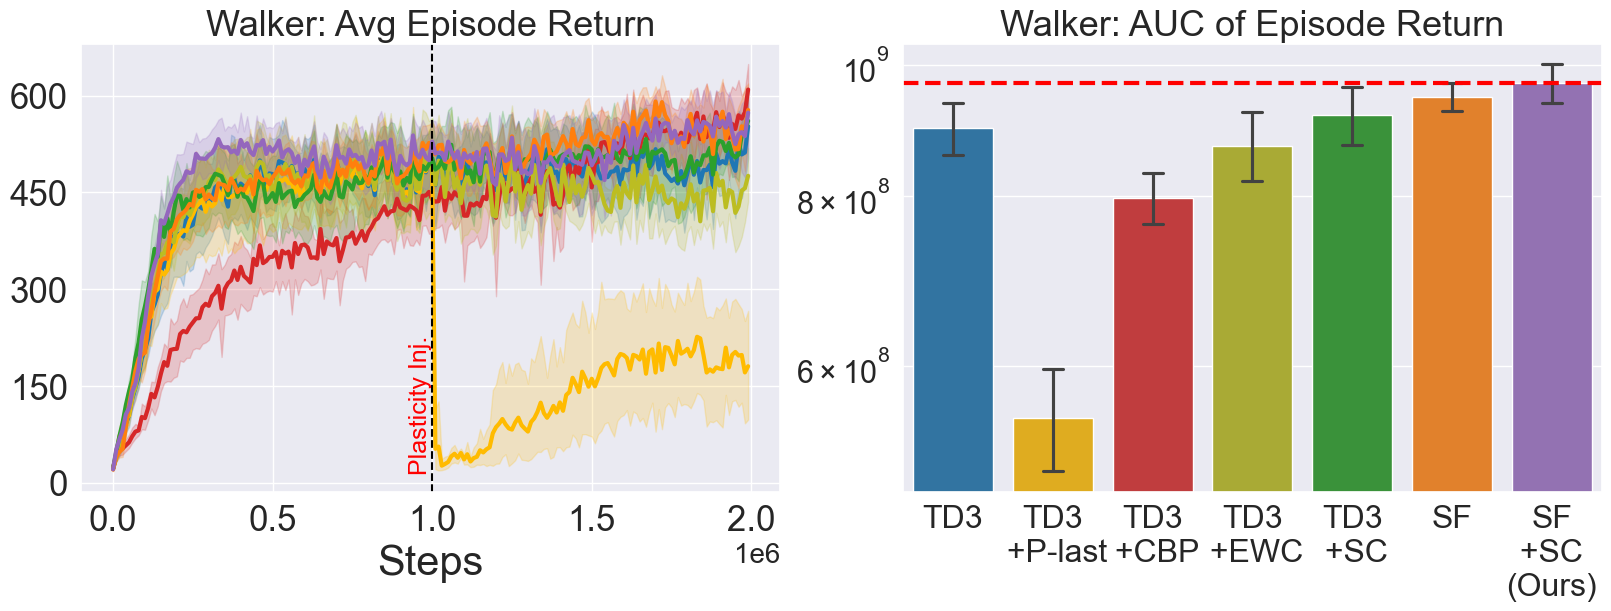

In [28]:
# Plot for Plasticity-Stability Analysis

from matplotlib.ticker import MaxNLocator, LogLocator

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
# LEFT

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
    label=agents_new_names["ddpg"],
    color=color_code[agents_new_names["ddpg"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
     ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_continual_backprop"]],
    label=agents_new_names["ddpg_continual_backprop"],
    color=color_code[agents_new_names["ddpg_continual_backprop"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)


sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_plasticity_injection_last_layer"]],
    label=agents_new_names["ddpg_plasticity_injection_last_layer"],
    color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0]
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_online_ewc"]],
    label=agents_new_names["ddpg_online_ewc"],
    color=color_code[agents_new_names["ddpg_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]],
    label=agents_new_names["sf_simple"],
    color=color_code[agents_new_names["sf_simple"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

xline = 1000000
ymin, ymax = axes[0].get_ylim()

axes[0].axvline(x=xline, color="black", linestyle="--", linewidth=1.5)
axes[0].text(
    xline,                      # x position (same as line)
    ymin + 0.35* (ymax - ymin),   # 40% above the bottom,
    "Plasticity Inj.",
    rotation=90,                # vertical text
    color="red",
    ha="right", va="top",       # horizontal/vertical alignment
    fontsize=18
)


# Right
def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/step"])
auc_df = (
    runs_df.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

# last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)
agents_to_plot = ["TD3", "TD3 + P-last", "TD3 + CBP", "TD3 + EWC", "TD3 + SC", "SF","SF + SC (Ours)"]
# agents_to_plot = ["TD3", "TD3 + CBP", "TD3 + EWC", "TD3 + SC", "SF + SC (Ours)"]
subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]
subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
subset["agent_name_pretty"] = subset["agent_name_pretty"].str.replace(
    "SF\n +SC (Ours)", "SF\n +SC \n(Ours)", regex=False
)
# agents_to_plot is defined earlier
agents_order = [name.replace(" + ", "\n +") for name in agents_to_plot]
agents_order[-1] = "SF\n +SC \n(Ours)"
subset["agent_name_pretty"] = pd.Categorical(subset["agent_name_pretty"],
                                             categories=agents_order,
                                             ordered=True)
ax = sns.barplot(data=subset, x="agent_name_pretty", y="AUC", palette=color_code, errorbar="se", capsize=0.2, hue="agent_name_pretty")

mean_val = subset[subset["agent_name"] == agents_new_names["sf_simple_beakers_params"]]["AUC"].mean()
ax.axhline(mean_val, color="red", linestyle="--", linewidth=3)

# fig.suptitle("Consolidating Q-values vs SFs under Mass Changes", fontsize=18)

axes[0].set_title("Walker: Avg Episode Return", fontsize=26)
axes[0].set_xlabel("Steps", fontsize=30)
axes[0].set_ylabel("", fontsize=30)
# axes[0].legend(loc="upper left", fontsize=16, ncol=2)
axes[0].legend().set_visible(False)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].xaxis.get_offset_text().set_fontsize(20)
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[1].set_xlabel("", fontsize=14)
axes[1].set_ylabel("", fontsize=26)
axes[1].set_title("Walker: AUC of Episode Return", fontsize=26)
axes[1].tick_params(axis="x", labelsize=23)
axes[1].tick_params(axis="y", labelsize=22, which="both")
axes[1].set_yscale("log")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks
axes[1].yaxis.get_offset_text().set_visible(False)


filename = "plasticity_stability_analysis_with_sf_" + domain + "_" + cfg.mode + "_OU"
fig.savefig(filename + ".pdf", bbox_inches="tight")
plt.show()


/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_41623/2885177558.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_41623/2885177558.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name_pretty"].str.replace(
/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_41623/2885177558.py:72: SettingWi

['SF', 'SF\n +SC \n(Ours)', 'TD3', 'TD3\n +SC']
Categories (4, object): ['TD3' < 'TD3\n +SC' < 'SF' < 'SF\n +SC \n(Ours)']


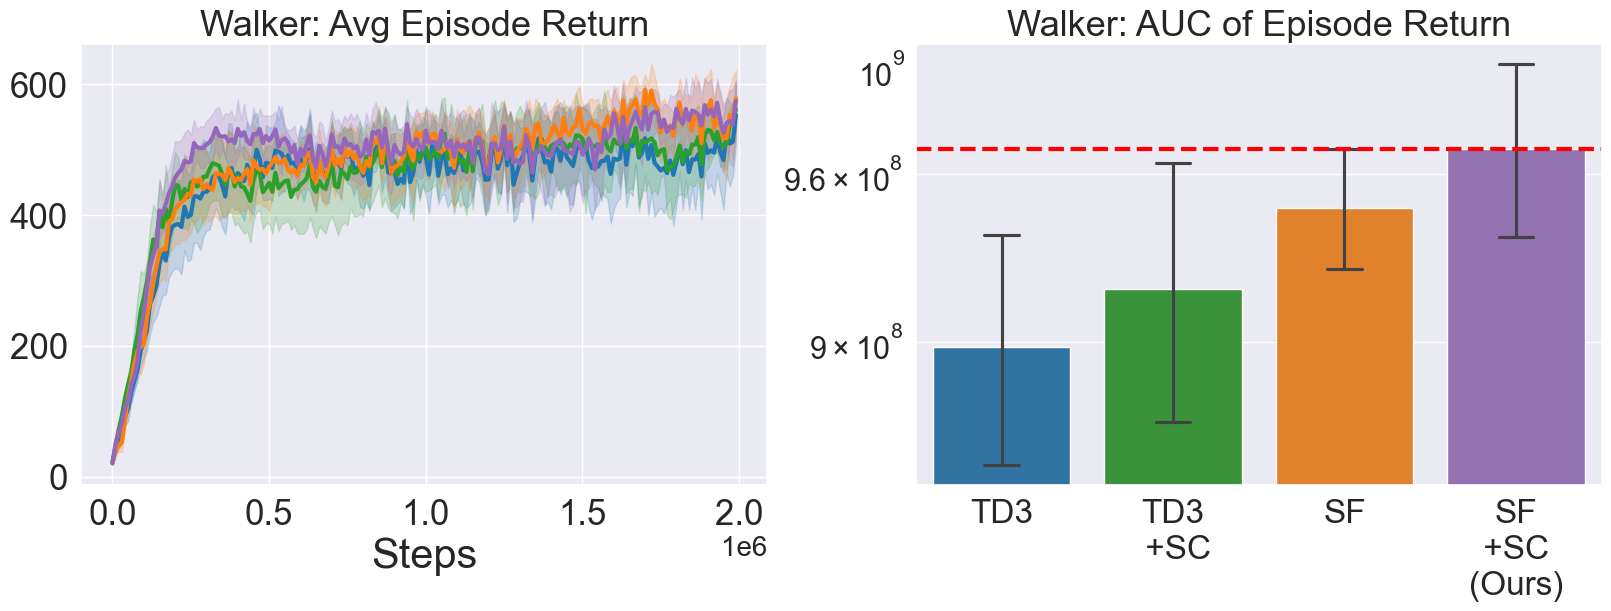

In [40]:
# plot is it better to consolidate parameters of Q-values or SFs?

from matplotlib.ticker import MaxNLocator, LogLocator

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
# LEFT

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
    label=agents_new_names["ddpg"],
    color=color_code[agents_new_names["ddpg"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
     ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]],
    label=agents_new_names["sf_simple"],
    color=color_code[agents_new_names["sf_simple"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

# Right
def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/step"])
auc_df = (
    runs_df.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

agents_to_plot = ["TD3", "TD3 + SC", "SF", "SF + SC (Ours)",]
subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]
subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
subset["agent_name_pretty"] = subset["agent_name_pretty"].str.replace(
    "SF\n +SC (Ours)", "SF\n +SC \n(Ours)", regex=False
)
# agents_to_plot is defined earlier
agents_order = [name.replace(" + ", "\n +") for name in agents_to_plot]
agents_order[-1] = "SF\n +SC \n(Ours)"


# Ensure subset has the pretty labels and exact category order
# subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
# subset.loc[subset["agent_name_pretty"] == "SF\n +SC (Ours)", "agent_name_pretty"] = "SF\n + SC \n(Ours)"

subset["agent_name_pretty"] = pd.Categorical(subset["agent_name_pretty"],
                                             categories=agents_order,
                                             ordered=True)
print(subset["agent_name_pretty"].unique())

ax = sns.barplot(data=subset, x="agent_name_pretty", y="AUC", palette=color_code, errorbar="se", capsize=0.2, hue="agent_name_pretty")

mean_val = subset[subset["agent_name"] == agents_new_names["sf_simple_beakers_params"]]["AUC"].mean()
ax.axhline(mean_val, color="red", linestyle="--", linewidth=3)

axes[0].set_title("Walker: Avg Episode Return", fontsize=26)
axes[0].set_xlabel("Steps", fontsize=30)
axes[0].set_ylabel("", fontsize=30)
# axes[0].legend(loc="lower right", fontsize=18)
axes[0].legend().set_visible(False)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].xaxis.get_offset_text().set_fontsize(20)

axes[1].set_xlabel("", fontsize=14)
axes[1].set_ylabel("", fontsize=14)
axes[1].set_title("Walker: AUC of Episode Return", fontsize=26)
axes[1].tick_params(axis="x", labelsize=24)
axes[1].tick_params(axis="y", labelsize=22, which="both")
axes[1].set_yscale("log")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))

filename = "consolidate_qvals_sf_analysis_ou" + domain + "_" + cfg.mode
fig.savefig(filename + ".pdf", bbox_inches="tight")
plt.show()
